In [ ]:
from behave_analysis.database.Experiments.JAL003_ex import JAL3_25aug, JAL3_1sept, JAL3_4sept, JAL3_7sept
from behave_analysis.database.Experiments.JAL004_ex import JAL4_3rdSept, JAL4_19thSept, JAL4_28aug, JAL4_11thSept
from behave_analysis.database.Experiments.JAL005_ex import JAL005_8thSept, JAL005_21stSept
from behave_analysis.database.Experiments.JAL006_ex import JAL6_28mar, JAL6_flip4_21mar, JAL6_flip5_25mar, JAL6_flip3_18mar, JAL6_flip7_1apr
from behave_analysis.database.Experiments.JAL007_ex import JAL7_sesh8_9apr, JAL7_sesh9_16apr, JAL7_flip5_22mar, JAL7_flip2_12mar, JAL7_23apr, JAL7_30apr
from behave_analysis.database.Experiments.JAL008_ex import JAL8_flip1_25apr, JAL8_flip2_29apr, JAL8_tiny_3may, JAL8_flip4_10may, JAL8_14may, JAL8_21may

experiments_objects = [JAL6_flip7_1apr, JAL6_flip3_18mar, JAL6_flip4_21mar, JAL6_flip5_25mar, JAL6_28mar,
                       JAL3_25aug, JAL3_1sept, JAL3_4sept, JAL3_7sept,
                       JAL005_8thSept, JAL005_21stSept,
                       JAL7_sesh8_9apr, JAL7_sesh9_16apr, JAL7_flip5_22mar, JAL7_flip2_12mar, JAL7_23apr,
                       JAL8_flip1_25apr, JAL8_flip2_29apr, JAL8_flip4_10may, JAL8_14may,
                       JAL4_3rdSept, JAL4_19thSept, JAL4_28aug, JAL4_11thSept]

session_names = ["JAL6_flip7_1apr", "JAL6_flip3_18mar", "JAL6_flip4_21mar", "JAL6_flip5_25mar", "JAL6_28mar",
                 "JAL3_25aug", "JAL3_1sept", "JAL3_4sept", "JAL3_7sept", "JAL005_8thSept", "JAL005_21stSept",
                 "JAL5_8thSept", "JAL5_21stSept",
                 "JAL7_sesh8_9apr", "JAL7_sesh9_16apr", "JAL7_flip5_22mar", "JAL7_flip2_12mar", "JAL7_23apr",
                 "JAL8_flip1_25apr", "JAL8_flip2_29apr", "JAL8_flip4_10may", "JAL8_14may",
                 "JAL4_3rdSept", "JAL4_19thSept", "JAL4_28aug", "JAL4_11thSept"]

tinny_barrier = [JAL8_tiny_3may, JAL8_21may, JAL7_30apr]

# Mice groups based on session names
mice_groups = {
    "JAL6": ['JAL6_flip7_1apr', 'JAL6_flip3_18mar', 'JAL6_flip4_21mar', 'JAL6_flip5_25mar', 'JAL6_28mar'],
    "JAL3": ['JAL3_25aug', 'JAL3_1sept', 'JAL3_4sept', 'JAL3_7sept'],
    "JAL7": ['JAL7_sesh8_9apr', 'JAL7_sesh9_16apr', 'JAL7_flip5_22mar', 'JAL7_flip2_12mar', 'JAL7_23apr'],
    "JAL8": ['JAL8_flip1_25apr', 'JAL8_flip2_29apr', 'JAL8_flip4_10may', 'JAL8_14may'],
    "JAL4": ['JAL4_3rdSept', 'JAL4_19thSept', 'JAL4_28aug', 'JAL4_11thSept'],
    "JAL5": ['JAL5_8thSept', 'JAL5_21stSept']}

2025-09-25 10:24:18.169 | SUCCESS  | __main__:save_cell_ids:142 - HSA cell ids saved -> Z:\Jasmine_Laurence\Experimental_Data\JAL006\JAL006_shelter_barrier_flip_7_take2_2024_04_01T11_24_46\processed_data\cells\hsa_cells.pkl
2025-09-25 10:24:18.185 | INFO     | __main__:run_all_sessions:259 - Mouse: JAL006, Experiment: flip, Run number: 7 (JAL6): HSA 19 / 271
2025-09-25 10:24:18.191 | WARNING  | __main__:run_all_sessions:262 - [SKIP] Mouse: JAL006, Experiment: flip, Run number: 3: Access is denied. (os error 5): ...cessed_data\models\Rayleigh\good\experimental_conditions\shelter_only\hsa_Rayleigh.arrow
2025-09-25 10:24:18.193 | WARNING  | __main__:run_all_sessions:262 - [SKIP] Mouse: JAL006, Experiment: flip, Run number: 4: Access is denied. (os error 5): ...cessed_data\models\Rayleigh\good\experimental_conditions\shelter_only\hsa_Rayleigh.arrow
2025-09-25 10:24:18.247 | SUCCESS  | __main__:save_cell_ids:142 - HSA cell ids saved -> Z:\Jasmine_Laurence\Experimental_Data\JAL006\JAL006_she

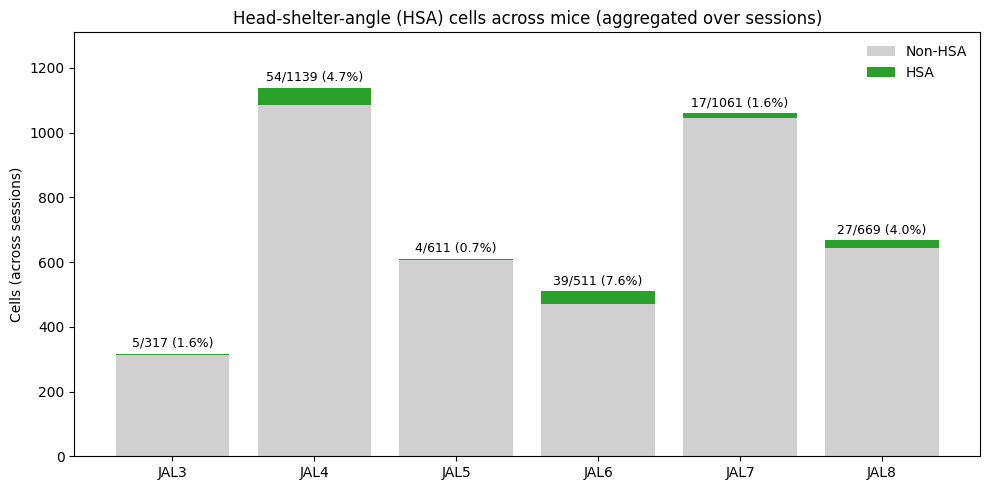

In [5]:
# classify_hsa_cells.py

import os
import re
import dill as pickle
import numpy as np
from collections import defaultdict
from loguru import logger

# ---- Your experiment/session imports ----
from behave_analysis.process.session import get_experiment
from behave_analysis.utils.creating_directories import make_directory
from behave_analysis.utils.rayleigh.load_rayleigh import extract_rayleigh_path, load_rayleigh_data
from behave_analysis.utils.rayleigh.manipulate_rayleigh_df import extract_compartment_values

# ------------------- USER CONFIG -------------------
RAYLEIGH_THRESHOLD = 0.3          # your spec
SIMILAR_ANGLE_THRESHOLD = 0.8     # your spec (0..1, higher = more similar)
CLUSTER_TYPE = "good"             # "good" or "curated" etc.

# If you already save HD cells per session, set this to the filename to auto-load and exclude.
# If not available, you can pass a list explicitly to classify_hsa(...).
HD_CELLS_FILENAME = "hdir_cells.pkl"

# Where to write the cross-session summary CSV
SUMMARY_CSV = r"Z:\Laurence\thesis\efizz_chapter\hsa_summary_counts.csv"

# ------------------- SESSIONS (from your message) -------------------
from behave_analysis.database.Experiments.JAL003_ex import JAL3_25aug, JAL3_1sept, JAL3_4sept, JAL3_7sept
from behave_analysis.database.Experiments.JAL004_ex import JAL4_3rdSept, JAL4_19thSept, JAL4_28aug, JAL4_11thSept
from behave_analysis.database.Experiments.JAL005_ex import JAL005_8thSept, JAL005_21stSept
from behave_analysis.database.Experiments.JAL006_ex import JAL6_28mar, JAL6_flip4_21mar, JAL6_flip5_25mar, JAL6_flip3_18mar, JAL6_flip7_1apr
from behave_analysis.database.Experiments.JAL007_ex import JAL7_sesh8_9apr, JAL7_sesh9_16apr, JAL7_flip5_22mar, JAL7_flip2_12mar, JAL7_23apr, JAL7_30apr
from behave_analysis.database.Experiments.JAL008_ex import JAL8_flip1_25apr, JAL8_flip2_29apr, JAL8_tiny_3may, JAL8_flip4_10may, JAL8_14may, JAL8_21may

experiments_objects = [
    JAL6_flip7_1apr, JAL6_flip3_18mar, JAL6_flip4_21mar, JAL6_flip5_25mar, JAL6_28mar,
    JAL3_25aug, JAL3_1sept, JAL3_4sept, JAL3_7sept,
    JAL005_8thSept, JAL005_21stSept,
    JAL7_sesh8_9apr, JAL7_sesh9_16apr, JAL7_flip5_22mar, JAL7_flip2_12mar, JAL7_23apr,
    JAL8_flip1_25apr, JAL8_flip2_29apr, JAL8_flip4_10may, JAL8_14may,
    JAL4_3rdSept, JAL4_19thSept, JAL4_28aug, JAL4_11thSept
]

tinny_barrier = [JAL8_tiny_3may, JAL8_21may, JAL7_30apr]

mice_groups = {
    "JAL6": ['JAL6_flip7_1apr', 'JAL6_flip3_18mar', 'JAL6_flip4_21mar', 'JAL6_flip5_25mar', 'JAL6_28mar'],
    "JAL3": ['JAL3_25aug', 'JAL3_1sept', 'JAL3_4sept', 'JAL3_7sept'],
    "JAL7": ['JAL7_sesh8_9apr', 'JAL7_sesh9_16apr', 'JAL7_flip5_22mar', 'JAL7_flip2_12mar', 'JAL7_23apr'],
    "JAL8": ['JAL8_flip1_25apr', 'JAL8_flip2_29apr', 'JAL8_flip4_10may', 'JAL8_14may'],
    "JAL4": ['JAL4_3rdSept', 'JAL4_19thSept', 'JAL4_28aug', 'JAL4_11thSept'],
    "JAL5": ['JAL5_8thSept', 'JAL5_21stSept'],
}

# ------------------- BACKEND-SAFE HELPERS -------------------
def _to_list_like(col):
    if hasattr(col, "to_list"):   # Polars Series
        return col.to_list()
    if hasattr(col, "tolist"):    # NumPy/Pandas
        return col.tolist()
    try:
        return list(col)
    except Exception:
        return []

def column_as_list(df, name, default=None):
    if default is None:
        default = []
    if df is None:
        return default
    if isinstance(df, dict):
        return _to_list_like(df.get(name, default))
    cols = getattr(df, "columns", None)
    if cols is not None and name in cols:
        try:
            return _to_list_like(df[name])
        except Exception:
            return default
    return default

def canonicalize_mouse(label: str) -> str:
    m = re.search(r"(JAL)0*([0-9]+)", label or "")
    if m:
        return f"{m.group(1)}{int(m.group(2))}"
    return label or "UNKNOWN"

def infer_mouse(session, session_to_mouse):
    session_name = getattr(session, "name", "")
    if session_name in session_to_mouse:
        return session_to_mouse[session_name]
    for attr in ("mouse", "mouse_id", "mouse_name"):
        val = getattr(session, attr, None)
        if isinstance(val, str) and val:
            return canonicalize_mouse(val)
    m = re.search(r"Mouse:\s*(JAL0*\d+|JAL\d+)", str(session))
    if m:
        return canonicalize_mouse(m.group(1))
    return "UNKNOWN"

# ------------------- CORE LOGIC -------------------
def angle_similarity(theta1: float, theta2: float) -> float:
    """
    Similarity in [0,1], higher = more similar.
    Uses cosine of circular difference (map from [-1,1] -> [0,1]).
    """
    delta = np.angle(np.exp(1j * (theta1 - theta2)))  # wraps to [-pi, pi]
    cos_sim = float(np.cos(delta))                    # [-1, 1]
    return 0.5 * (cos_sim + 1.0)                      # [0, 1]

def rayleigh_threshold(m1: float, m2: float) -> bool:
    return (m1 >= RAYLEIGH_THRESHOLD) and (m2 >= RAYLEIGH_THRESHOLD)

def check_both_compartments_significant(sig_pair) -> bool:
    try:
        return bool(sig_pair[0]) and bool(sig_pair[1])
    except Exception:
        return False

def load_hd_cells_if_available(session, filename=HD_CELLS_FILENAME):
    """
    Try to load a per-session list of HD cells from processed/cells/<filename>.
    Returns [] if not found, or any error occurs.
    """
    try:
        cells_dir = make_directory(os.path.join(session.base_path, session.processed_path, "cells"))
        fpath = os.path.join(cells_dir, filename)
        if os.path.exists(fpath):
            with open(fpath, "rb") as f:
                hd_cells = pickle.load(f)
                if isinstance(hd_cells, (list, tuple, set)):
                    return set(hd_cells)
    except Exception:
        pass
    return set()

def save_cell_ids(session, cell_ids, fname="hsa_cells.pkl") -> None:
    path = make_directory(os.path.join(session.base_path, session.processed_path, "cells"))
    file_name = os.path.join(path, fname)
    with open(file_name, "wb") as dill_file:
        pickle.dump(list(cell_ids), dill_file)
    logger.success(f"HSA cell ids saved -> {file_name}")

def classify_hsa(session, cluster_type: str = CLUSTER_TYPE, hdir_cells=None, save: bool = True):
    """
    Classify Head Shelter Angle (HSA) cells for a single session.

    Criteria:
      1) Rayleigh angle similar across compartments (shelter condition data), similarity > SIMILAR_ANGLE_THRESHOLD
      2) Rayleigh magnitude > RAYLEIGH_THRESHOLD in both compartments
      3) Both compartments significant
      4) Exclude clusters listed in hdir_cells (HD cells)

    Returns:
      list of clusterIDs (HSA cells)
    """
    # Load rayleigh dataframe (shelter_only)
    path = extract_rayleigh_path(session, cluster_type, condition="shelter_only", file_name="hsa_Rayleigh.arrow")
    data = load_rayleigh_data(path)

    cluster_ids = column_as_list(data, "clusterID", default=[])
    if len(cluster_ids) == 0:
        logger.warning("No clusters found in Rayleigh data.")
        if save:
            save_cell_ids(session, [])
        return []

    angles = extract_compartment_values(data, "Rayleigh_theta")  # [[theta_shelter, theta_barrier], ...]
    mags   = extract_compartment_values(data, "Rayleigh")        # [[mag_shelter, mag_barrier], ...]
    sigs   = extract_compartment_values(data, "Rayleigh_sig")    # [[sig_shelter, sig_barrier], ...]

    # Resolve HD (head-direction) exclusion list
    hd_set = set(hdir_cells) if isinstance(hdir_cells, (list, tuple, set)) else load_hd_cells_if_available(session)

    hsa_cells = []
    for i, cid in enumerate(cluster_ids):
        try:
            sim = angle_similarity(angles[i][0], angles[i][1])
            above = rayleigh_threshold(mags[i][0], mags[i][1])
            sig   = check_both_compartments_significant(sigs[i])
            if (sim > SIMILAR_ANGLE_THRESHOLD) and above and sig and (cid not in hd_set):
                hsa_cells.append(cid)
        except Exception as e:
            logger.warning(f"Skipping cluster index {i} ({cid}) due to error: {e}")
            continue

    if save:
        save_cell_ids(session, hsa_cells)

    return hsa_cells

# --- ADD: plotting (like your HD plot) ---
import matplotlib.pyplot as plt

def plot_hsa_across_mice(per_mouse_counts, save_dir, fname="hsa_cells_across_mice.eps"):
    """
    per_mouse_counts: dict like { "JAL4": {"hsa": int, "total": int}, ... }
    Produces a stacked bar plot (Non-HSA vs HSA) with annotations.
    """
    # Order mice by label
    mice = sorted([m for m in per_mouse_counts.keys() if m != "UNKNOWN"]) or ["UNKNOWN"]
    totals = np.array([per_mouse_counts[m]["total"] for m in mice], dtype=int)
    hsas   = np.array([per_mouse_counts[m]["hsa"]   for m in mice], dtype=int)
    non_hsa = totals - hsas
    pct = np.where(totals > 0, 100.0 * hsas / totals, 0.0)

    fig, ax = plt.subplots(figsize=(10, 5))
    x = np.arange(len(mice))

    # Stacked bars (colors chosen to resemble your example; tweak if desired)
    ax.bar(x, non_hsa, label="Non-HSA", color="#d0d0d0")
    ax.bar(x, hsas, bottom=non_hsa, label="HSA", color="#2ca02c")

    # Annotations like "15/1061 (1.4%)"
    y_offset = max(1, totals.max()) * 0.01
    for i, (t, h, p) in enumerate(zip(totals, hsas, pct)):
        ax.text(i, t + y_offset, f"{h}/{t} ({p:.1f}%)", ha="center", va="bottom", fontsize=9)

    ax.set_xticks(x); ax.set_xticklabels(mice)
    ax.set_ylabel("Cells (across sessions)")
    ax.set_title("Head-shelter-angle (HSA) cells across mice (aggregated over sessions)")
    ax.legend(frameon=False)
    ax.set_ylim(0, max(1, totals.max()) * 1.15)
    plt.tight_layout()

    # Save
    os.makedirs(save_dir, exist_ok=True)
    out_path = os.path.join(save_dir, fname)
    plt.savefig(out_path, format="eps", dpi=300)
    logger.success(f"Saved HSA plot -> {out_path}")
    plt.show()
    #plt.close(fig)


# --- MODIFY: have run_all_sessions return per-mouse counts so we can plot ---
def run_all_sessions(experiments, mice_groups, cluster_type=CLUSTER_TYPE, summary_csv=SUMMARY_CSV):
    """
    Run HSA classification across all sessions in `experiments`.
    Writes per-session pkl and a cross-session CSV summary with counts.
    Returns:
        per_mouse (dict): {mouse: {"hsa": int, "total": int}}
    """
    session_to_mouse = {s: m for m, sessions in mice_groups.items() for s in sessions}

    records = []
    skipped = []

    for sess in experiments:
        session = get_experiment(sess)
        session_name = getattr(session, "name", str(session))
        mouse = infer_mouse(session, session_to_mouse)

        try:
            hsa = classify_hsa(session, cluster_type=cluster_type, hdir_cells=None, save=True)
            path = extract_rayleigh_path(session, cluster_type, condition="shelter_only", file_name="hsa_Rayleigh.arrow")
            data = load_rayleigh_data(path)
            total = len(column_as_list(data, "clusterID", default=[]))
            records.append((mouse, session_name, len(hsa), total))
            logger.info(f"{session_name} ({mouse}): HSA {len(hsa)} / {total}")
        except Exception as e:
            msg = str(e)
            logger.warning(f"[SKIP] {session_name}: {msg}")
            skipped.append((mouse, session_name, msg))
            continue

    # Aggregate per-mouse
    per_mouse = defaultdict(lambda: {"hsa": 0, "total": 0})
    for mouse, session_name, hsa_n, total_n in records:
        per_mouse[mouse]["hsa"]  += int(hsa_n)
        per_mouse[mouse]["total"] += int(total_n)

    # Write summary CSV
    try:
        lines = ["mouse,session,hsa_count,total_count,mouse_agg_hsa,mouse_agg_total,mouse_agg_pct"]
        for mouse, session_name, hsa_n, total_n in records:
            agg_hsa = per_mouse[mouse]["hsa"]
            agg_tot = per_mouse[mouse]["total"]
            pct = (100.0 * agg_hsa / agg_tot) if agg_tot > 0 else 0.0
            lines.append(f"{mouse},{session_name},{hsa_n},{total_n},{agg_hsa},{agg_tot},{pct:.2f}")

        out_dir = os.path.dirname(summary_csv)
        if out_dir and not os.path.exists(out_dir):
            os.makedirs(out_dir, exist_ok=True)
        with open(summary_csv, "w", encoding="utf-8") as f:
            f.write("\n".join(lines))
        logger.success(f"Wrote HSA summary CSV -> {summary_csv}")
    except Exception as e:
        logger.error(f"Failed to write summary CSV: {e}")

    if skipped:
        logger.warning(f"Skipped {len(skipped)} sessions.")
        reasons = defaultdict(int)
        for _, _, msg in skipped:
            reasons[msg.split(':')[0]] += 1
        for reason, cnt in sorted(reasons.items(), key=lambda x: -x[1]):
            logger.warning(f"  {reason}: {cnt}")

    return per_mouse


# --- MAIN: after run_all_sessions, call the plotter ---
if __name__ == "__main__":
    per_mouse = run_all_sessions(experiments_objects, mice_groups, cluster_type=CLUSTER_TYPE, summary_csv=SUMMARY_CSV)
    save_path = r"Z:\Laurence\thesis\efizz_chapter"
    plot_hsa_across_mice(per_mouse, save_path, fname="hsa_cells_across_mice.eps")
